## Using ivt to render an image

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image

In [2]:
from matplotlib import pyplot as plt

#### setting up a scene

In [47]:
scene = Scene()
diffuse = read_image('assets/polyhaven/textures/raw_plank_wall_diff_1k.exr')
black = (0,0,0)
scene.set('mat', DiffuseBRDF(diffuse))
scene.set('black', DiffuseBRDF(black))
scene.set('mesh1', Mesh.from_file("quad.obj", 'mat'))
scene.set('meshl', Mesh.from_file("light.obj", 'black', radiance=100))
# scene.set('envmap', EnvironmentLight.from_file('assets/polyhaven/envmaps/rural_asphalt_road_2k.exr'))
scene.set('film', HDRFilm(1280, 720))
scene.set('integrator', Integrator('path', {'max_depth': 3, 'hide_emitters': True}))
scene.set('cam1', PerspectiveCamera.from_lookat(fov=45, origin=(3,3,0), target=(0,0,0), up=(0,1,0)))

In [48]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})

In [49]:
t = renderer(scene)

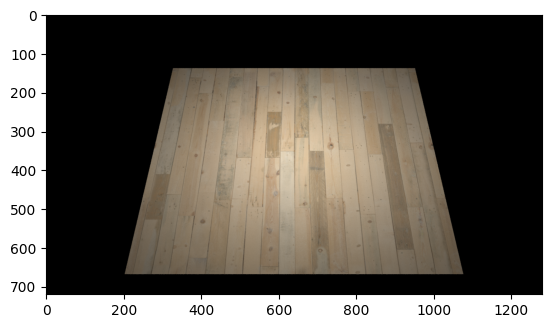

In [50]:
plt.imshow((t**0.454).cpu().numpy().squeeze(), vmax=1)

In [11]:
write_image('1.exr', t)

In [20]:
ivt.__file__

'C:\\ProgramData\\anaconda3\\envs\\ivt\\lib\\site-packages\\ivt\\__init__.py'

## Getting derivatives

In [45]:
# example of parameter
scene['mat']['d'].shape

torch.Size([1024, 1024, 3])

In [51]:
t.max()

tensor(0.8106, device='cuda:0')

In [69]:
param = scene['mat']['d']
param.requires_grad = True
scene.configure()
t = renderer(scene)
loss = t.sum()
loss.backward()

In [65]:
t.requires_grad

False

In [71]:
scene['mat']['d'].grad.shape

torch.Size([1024, 1024, 3])

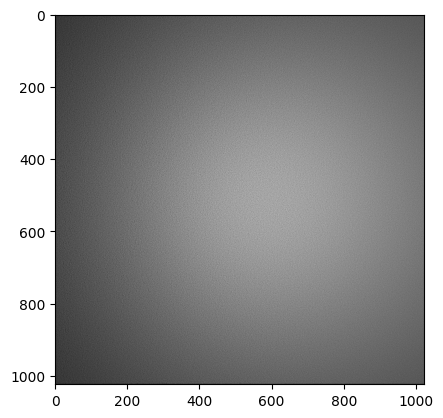

In [73]:
plt.imshow((param.grad**0.454).cpu().numpy().squeeze(), vmax=1)

In [75]:
param.grad.zero_();

In [77]:
param[500][500][1]

tensor(0.6094, device='cuda:0', grad_fn=<SelectBackward0>)